In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

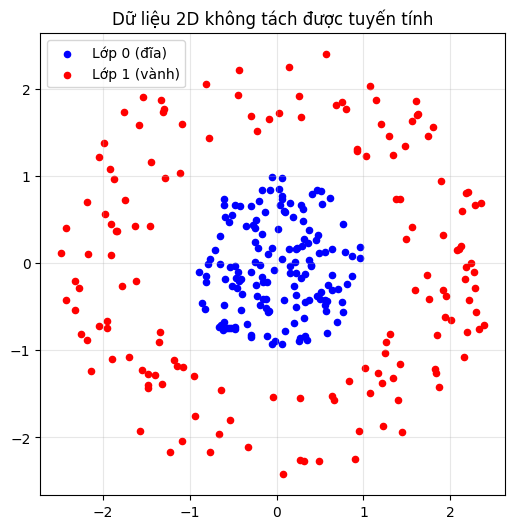

In [ ]:
def gen_disk(n, r_max=1.0):
    u = np.random.uniform(0, 1, n)
    theta = np.random.uniform(0, 2 * np.pi, n)
    r = r_max * np.sqrt(u)
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

def gen_ring(n, r_in=1.5, r_out=2.5):
    u = np.random.uniform(0, 1, n)
    theta = np.random.uniform(0, 2 * np.pi, n)
    r = np.sqrt(u * (r_out**2 - r_in**2) + r_in**2)
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

n_per_class = 150
X0 = gen_disk(n_per_class)
X1 = gen_ring(n_per_class)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

plt.figure(figsize=(6, 6))
plt.scatter(X0[:, 0], X0[:, 1], color='blue', label='Lớp 0 (đĩa)', s=20)
plt.scatter(X1[:, 0], X1[:, 1], color='red',  label='Lớp 1 (vành)', s=20)
plt.legend(); plt.axis('equal'); plt.grid(alpha=0.3)
plt.title('Dữ liệu 2D không tách được tuyến tính')
plt.show()

In [ ]:
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train = torch.FloatTensor(X_train_np)
y_train = torch.FloatTensor(y_train_np).unsqueeze(1)
X_test  = torch.FloatTensor(X_test_np)
y_test  = torch.FloatTensor(y_test_np).unsqueeze(1)

print(f'Train: {len(X_train)} điểm,  Test: {len(X_test)} điểm')

Train: 240 điểm,  Test: 60 điểm


In [ ]:
logreg = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())
opt_lr = optim.Adam(logreg.parameters(), lr=0.05)
for _ in range(300):
    opt_lr.zero_grad()
    loss = nn.BCELoss()(logreg(X_train), y_train)
    loss.backward(); opt_lr.step()

with torch.no_grad():
    pred = (logreg(X_test) > 0.5).float()
    acc_lr = (pred == y_test).float().mean().item()
print(f'Logistic regression accuracy: {acc_lr*100:.2f}%   (kỳ vọng quanh 50%)')

Logistic regression accuracy: 41.67%   (kỳ vọng quanh 50%)


In [ ]:
class ANN(nn.Module):
    def __init__(self, hidden_layer_sizes):
        super().__init__()
        layers = []
        input_size = 2 # Fixed input size for our 2D data

        for output_size in hidden_layer_sizes:
            layers.append(nn.Linear(input_size, output_size))
            layers.append(nn.ReLU())
            input_size = output_size

        # Output layer - BCEWithLogitsLoss expects raw logits, so no Sigmoid here
        layers.append(nn.Linear(input_size, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


In [ ]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=500, lr=0.01, optimizer_type='Adam', momentum=0.9, save_epochs=None):
    criterion = nn.BCEWithLogitsLoss()

    if optimizer_type == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_type == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    else:
        raise ValueError(f"Unsupported optimizer type: {optimizer_type}")

    loss_history, acc_history = [], []
    saved_models = {}

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_pred = (torch.sigmoid(model(X_test)) > 0.5).float()
            acc = (test_pred == y_test).float().mean().item()
        loss_history.append(loss.item())
        acc_history.append(acc)

        if save_epochs and (epoch + 1) in save_epochs:
            saved_models[epoch + 1] = model.state_dict() # Save model state_dict

    return loss_history, acc_history, model, saved_models


### Mô hình 1: 2 -> 4 (ReLU) -> 1 (Sigmoid)

ANN(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=1, bias=True)
  )
)
ANN (4 nodes) final test accuracy: 50.00%


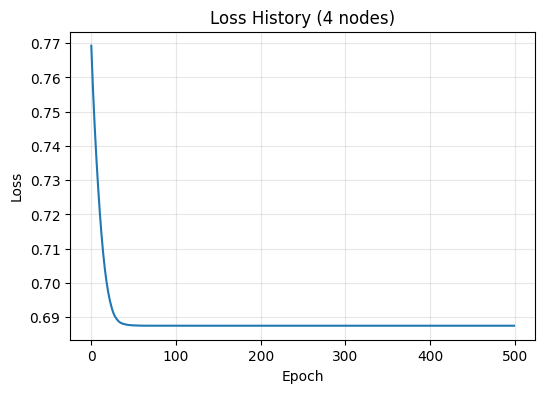

In [ ]:
model_4_nodes = ANN([4])
print(model_4_nodes)
loss_history_4, acc_history_4, model_4_nodes, _ = train_model(
    model_4_nodes, X_train, y_train, X_test, y_test, epochs=500, lr=0.01)

with torch.no_grad():
    pred_4 = (model_4_nodes(X_test) > 0.5).float()
    acc_ann_4 = (pred_4 == y_test).float().mean().item()
print(f'ANN (4 nodes) final test accuracy: {acc_ann_4*100:.2f}%')

plt.figure(figsize=(6, 4))
plt.plot(loss_history_4)
plt.title('Loss History (4 nodes)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

### Mô hình 2: 2 -> 8 (ReLU) -> 1 (Sigmoid)

ANN(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)
ANN (8 nodes) final test accuracy: 100.00%


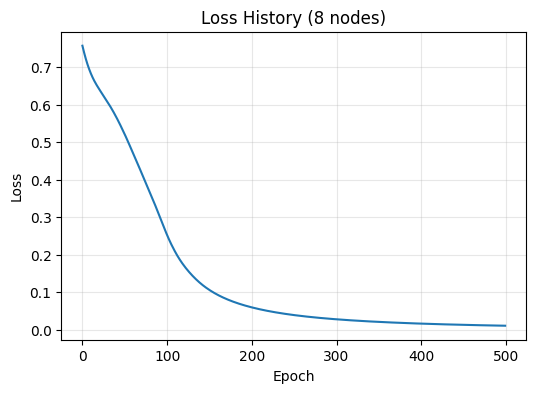

In [ ]:
model_8_nodes = ANN([8])
print(model_8_nodes)
loss_history_8, acc_history_8, model_8_nodes, _ = train_model(
    model_8_nodes, X_train, y_train, X_test, y_test, epochs=500, lr=0.01)

with torch.no_grad():
    pred_8 = (model_8_nodes(X_test) > 0.5).float()
    acc_ann_8 = (pred_8 == y_test).float().mean().item()
print(f'ANN (8 nodes) final test accuracy: {acc_ann_8*100:.2f}%')

plt.figure(figsize=(6, 4))
plt.plot(loss_history_8)
plt.title('Loss History (8 nodes)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

### Mô hình 3: 2 -> 8 (ReLU) -> 6 (ReLU) -> 1 (Sigmoid)

ANN(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=6, bias=True)
    (3): ReLU()
    (4): Linear(in_features=6, out_features=1, bias=True)
  )
)
ANN (8+6 nodes) final test accuracy: 100.00%


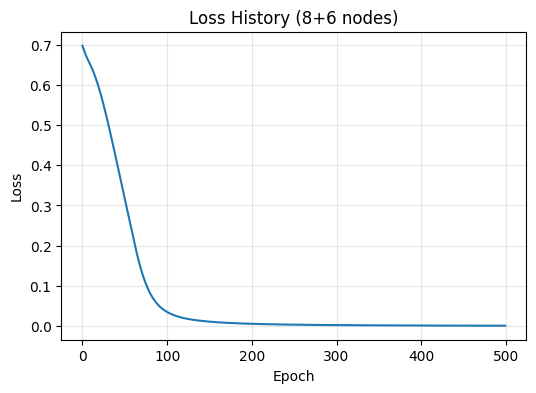

In [ ]:
model_8_6_nodes = ANN([8, 6])
print(model_8_6_nodes)
loss_history_8_6, acc_history_8_6, model_8_6_nodes, _ = train_model(
    model_8_6_nodes, X_train, y_train, X_test, y_test, epochs=500, lr=0.01)

with torch.no_grad():
    pred_8_6 = (model_8_6_nodes(X_test) > 0.5).float()
    acc_ann_8_6 = (pred_8_6 == y_test).float().mean().item()
print(f'ANN (8+6 nodes) final test accuracy: {acc_ann_8_6*100:.2f}%')

plt.figure(figsize=(6, 4))
plt.plot(loss_history_8_6)
plt.title('Loss History (8+6 nodes)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

### So sánh Loss của 3 mô hình

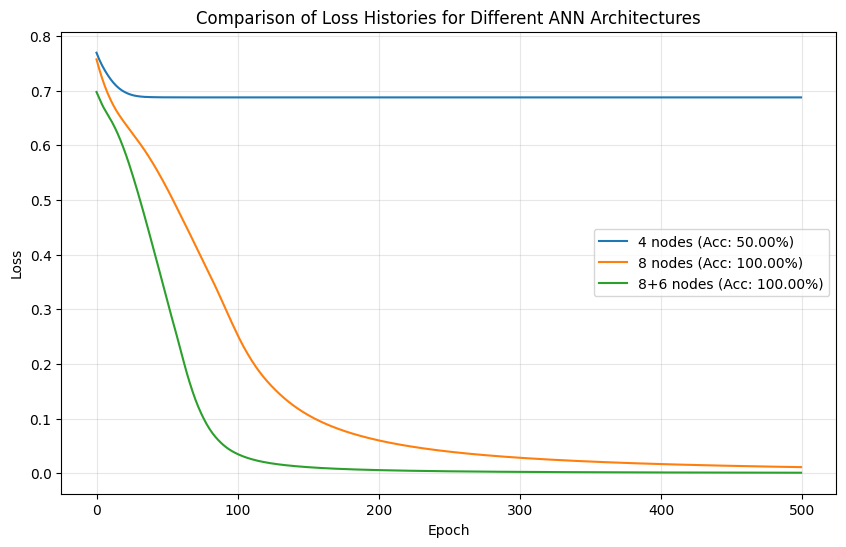

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(loss_history_4, label=f'4 nodes (Acc: {acc_ann_4*100:.2f}%)')
plt.plot(loss_history_8, label=f'8 nodes (Acc: {acc_ann_8*100:.2f}%)')
plt.plot(loss_history_8_6, label=f'8+6 nodes (Acc: {acc_ann_8_6*100:.2f}%)')
plt.title('Comparison of Loss Histories for Different ANN Architectures')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Phần 2: Loss và Optimizer - Sử dụng BCEWithLogitsLoss và so sánh Optimizers

#### Mô hình 8 nút với BCEWithLogitsLoss và Adam Optimizer

ANN(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)
ANN (8 nodes, BCEWithLogits, Adam) final test accuracy: 100.00%


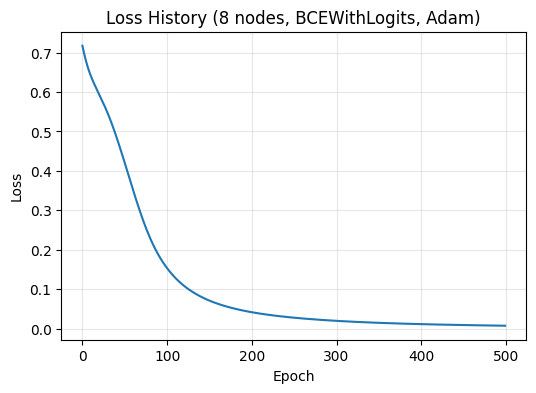

In [ ]:
# Re-initialize the 8-node model for a clean training run
model_8_nodes_bce_adam = ANN([8])
print(model_8_nodes_bce_adam)

loss_history_8_bce_adam, acc_history_8_bce_adam, _, _ = train_model(
    model_8_nodes_bce_adam, X_train, y_train, X_test, y_test,
    epochs=500, lr=0.01, optimizer_type='Adam')

with torch.no_grad():
    pred_8_bce_adam = (torch.sigmoid(model_8_nodes_bce_adam(X_test)) > 0.5).float()
    acc_ann_8_bce_adam = (pred_8_bce_adam == y_test).float().mean().item()
print(f'ANN (8 nodes, BCEWithLogits, Adam) final test accuracy: {acc_ann_8_bce_adam*100:.2f}%')

plt.figure(figsize=(6, 4))
plt.plot(loss_history_8_bce_adam)
plt.title('Loss History (8 nodes, BCEWithLogits, Adam)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

#### Mô hình 8 nút với BCEWithLogitsLoss và SGD Optimizer

ANN(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)
ANN (8 nodes, BCEWithLogits, SGD) final test accuracy: 100.00%


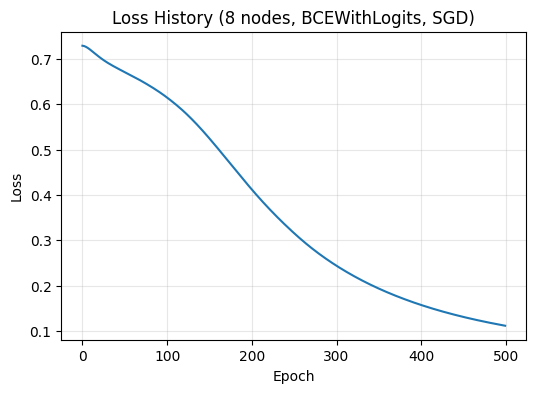

In [ ]:
# Re-initialize the 8-node model for a clean training run
model_8_nodes_bce_sgd = ANN([8])
print(model_8_nodes_bce_sgd)

loss_history_8_bce_sgd, acc_history_8_bce_sgd, _, _ = train_model(
    model_8_nodes_bce_sgd, X_train, y_train, X_test, y_test,
    epochs=500, lr=0.01, optimizer_type='SGD', momentum=0.9)

with torch.no_grad():
    pred_8_bce_sgd = (torch.sigmoid(model_8_nodes_bce_sgd(X_test)) > 0.5).float()
    acc_ann_8_bce_sgd = (pred_8_bce_sgd == y_test).float().mean().item()
print(f'ANN (8 nodes, BCEWithLogits, SGD) final test accuracy: {acc_ann_8_bce_sgd*100:.2f}%')

plt.figure(figsize=(6, 4))
plt.plot(loss_history_8_bce_sgd)
plt.title('Loss History (8 nodes, BCEWithLogits, SGD)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

#### So sánh tốc độ hội tụ của Adam và SGD (với BCEWithLogitsLoss)

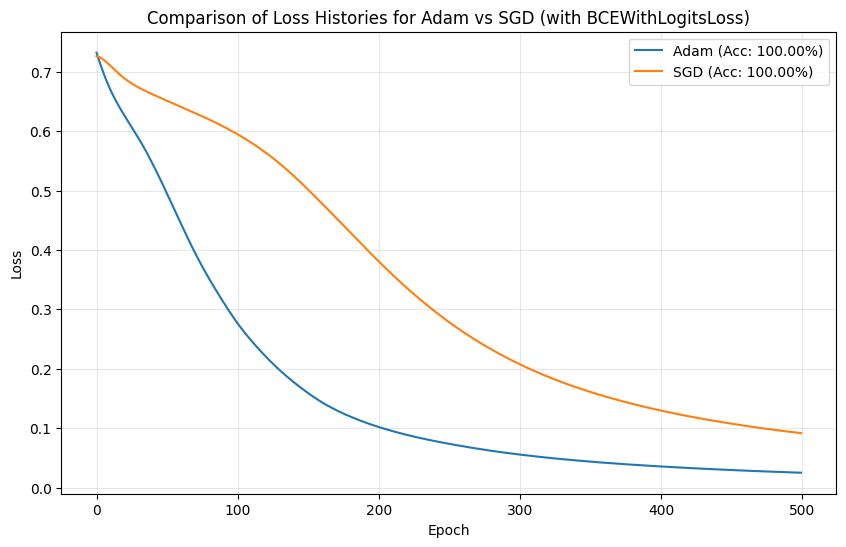

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(loss_history_8_bce_adam, label=f'Adam (Acc: {acc_ann_8_bce_adam*100:.2f}%)')
plt.plot(loss_history_8_bce_sgd, label=f'SGD (Acc: {acc_ann_8_bce_sgd*100:.2f}%)')
plt.title('Comparison of Loss Histories for Adam vs SGD (with BCEWithLogitsLoss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Phần 2: Loss và Optimizer - Sử dụng BCEWithLogitsLoss và so sánh Optimizers

#### Mô hình 8 nút với BCEWithLogitsLoss và Adam Optimizer

ANN(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)
ANN (8 nodes, BCEWithLogits, Adam) final test accuracy: 100.00%


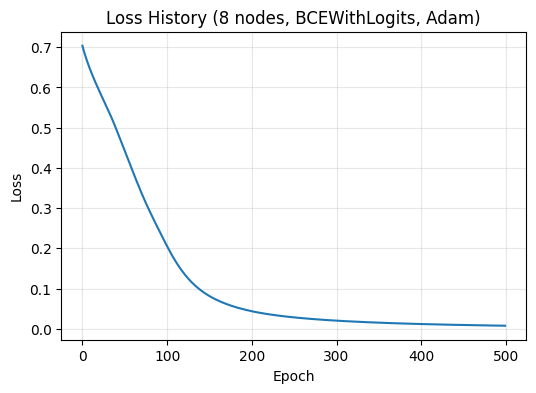

In [ ]:
# Re-initialize the 8-node model for a clean training run
model_8_nodes_bce_adam = ANN([8])
print(model_8_nodes_bce_adam)

loss_history_8_bce_adam, acc_history_8_bce_adam, _ = train_model(
    model_8_nodes_bce_adam, X_train, y_train, X_test, y_test,
    epochs=500, lr=0.01, optimizer_type='Adam')

with torch.no_grad():
    pred_8_bce_adam = (torch.sigmoid(model_8_nodes_bce_adam(X_test)) > 0.5).float()
    acc_ann_8_bce_adam = (pred_8_bce_adam == y_test).float().mean().item()
print(f'ANN (8 nodes, BCEWithLogits, Adam) final test accuracy: {acc_ann_8_bce_adam*100:.2f}%')

plt.figure(figsize=(6, 4))
plt.plot(loss_history_8_bce_adam)
plt.title('Loss History (8 nodes, BCEWithLogits, Adam)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

#### Mô hình 8 nút với BCEWithLogitsLoss và SGD Optimizer

ANN(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)
ANN (8 nodes, BCEWithLogits, SGD) final test accuracy: 98.33%


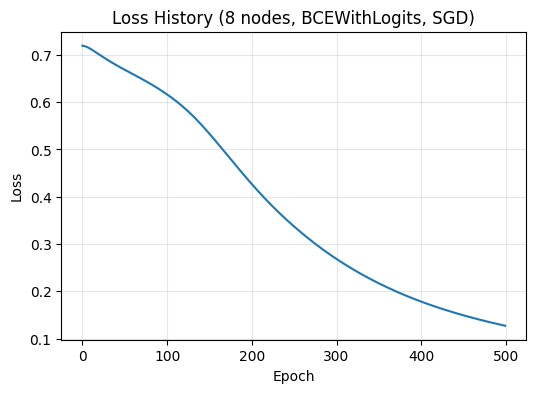

In [ ]:
# Re-initialize the 8-node model for a clean training run
model_8_nodes_bce_sgd = ANN([8])
print(model_8_nodes_bce_sgd)

loss_history_8_bce_sgd, acc_history_8_bce_sgd, _ = train_model(
    model_8_nodes_bce_sgd, X_train, y_train, X_test, y_test,
    epochs=500, lr=0.01, optimizer_type='SGD', momentum=0.9)

with torch.no_grad():
    pred_8_bce_sgd = (torch.sigmoid(model_8_nodes_bce_sgd(X_test)) > 0.5).float()
    acc_ann_8_bce_sgd = (pred_8_bce_sgd == y_test).float().mean().item()
print(f'ANN (8 nodes, BCEWithLogits, SGD) final test accuracy: {acc_ann_8_bce_sgd*100:.2f}%')

plt.figure(figsize=(6, 4))
plt.plot(loss_history_8_bce_sgd)
plt.title('Loss History (8 nodes, BCEWithLogits, SGD)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

#### So sánh tốc độ hội tụ của Adam và SGD (với BCEWithLogitsLoss)

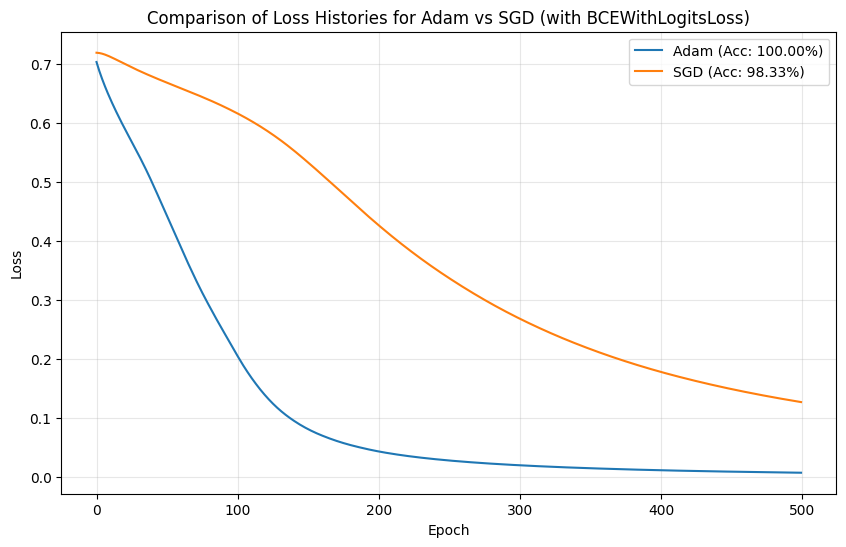

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(loss_history_8_bce_adam, label=f'Adam (Acc: {acc_ann_8_bce_adam*100:.2f}%)')
plt.plot(loss_history_8_bce_sgd, label=f'SGD (Acc: {acc_ann_8_bce_sgd*100:.2f}%)')
plt.title('Comparison of Loss Histories for Adam vs SGD (with BCEWithLogitsLoss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Phần 3: Phân tích sâu - Ảnh hưởng của Learning Rate và ranh giới quyết định

#### Huấn luyện mô hình 8 nút với các Learning Rate khác nhau

In [ ]:
# Training with lr = 0.001
model_lr_0001 = ANN([8])
loss_history_lr_0001, acc_history_lr_0001, _, _ = train_model(
    model_lr_0001, X_train, y_train, X_test, y_test, epochs=500, lr=0.001, optimizer_type='Adam')

# Training with lr = 0.01
model_lr_001 = ANN([8])
save_epochs_list = [10, 100, 500]
loss_history_lr_001, acc_history_lr_001, _, saved_models_lr_001 = train_model(
    model_lr_001, X_train, y_train, X_test, y_test, epochs=500, lr=0.01, optimizer_type='Adam', save_epochs=save_epochs_list)

# Training with lr = 0.1
model_lr_01 = ANN([8])
loss_history_lr_01, acc_history_lr_01, _, _ = train_model(
    model_lr_01, X_train, y_train, X_test, y_test, epochs=500, lr=0.1, optimizer_type='Adam')

# Get final accuracies for plotting labels
with torch.no_grad():
    acc_0001 = (torch.sigmoid(model_lr_0001(X_test)) > 0.5).float().mean().item()
    acc_001 = (torch.sigmoid(model_lr_001(X_test)) > 0.5).float().mean().item()
    acc_01 = (torch.sigmoid(model_lr_01(X_test)) > 0.5).float().mean().item()

print(f'Final Accuracy (lr=0.001): {acc_0001*100:.2f}%')
print(f'Final Accuracy (lr=0.01): {acc_001*100:.2f}%')
print(f'Final Accuracy (lr=0.1): {acc_01*100:.2f}%')

Final Accuracy (lr=0.001): 46.67%
Final Accuracy (lr=0.01): 50.00%
Final Accuracy (lr=0.1): 50.00%


#### So sánh Loss của các Learning Rate khác nhau

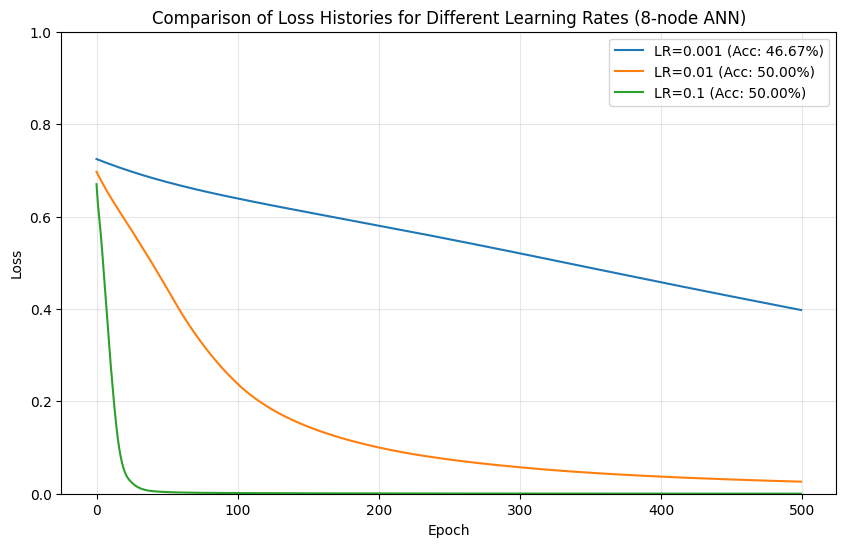

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(loss_history_lr_0001, label=f'LR=0.001 (Acc: {acc_0001*100:.2f}%)')
plt.plot(loss_history_lr_001, label=f'LR=0.01 (Acc: {acc_001*100:.2f}%)')
plt.plot(loss_history_lr_01, label=f'LR=0.1 (Acc: {acc_01*100:.2f}%)')
plt.title('Comparison of Loss Histories for Different Learning Rates (8-node ANN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1) # Set y-limit to better observe oscillations if any
plt.show()

#### Mô tả ảnh hưởng của Learning Rate:
*   **Learning Rate quá nhỏ (0.001):** Loss giảm rất chậm, cần nhiều epoch hơn để hội tụ.
*   **Learning Rate vừa phải (0.01):** Loss giảm nhanh và ổn định, đạt hội tụ tốt trong 500 epoch.
*   **Learning Rate quá lớn (0.1):** Loss giảm nhanh ban đầu nhưng có thể dao động hoặc thậm chí tăng trở lại (explode) nếu quá lớn. Trong trường hợp này, nó vẫn hội tụ nhưng có vẻ không mượt mà như `lr=0.01`.

#### Vẽ ranh giới quyết định ở các Epoch 10, 100, 500 (dùng mô hình với LR=0.01)

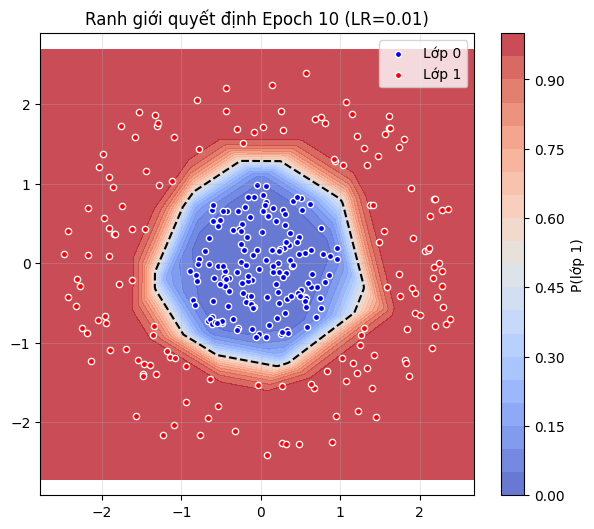

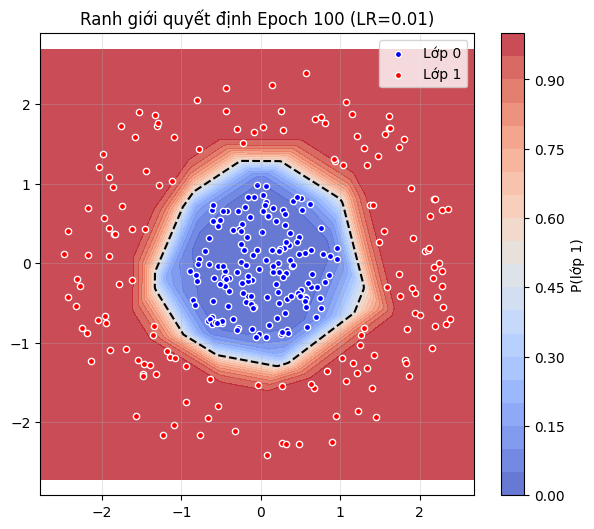

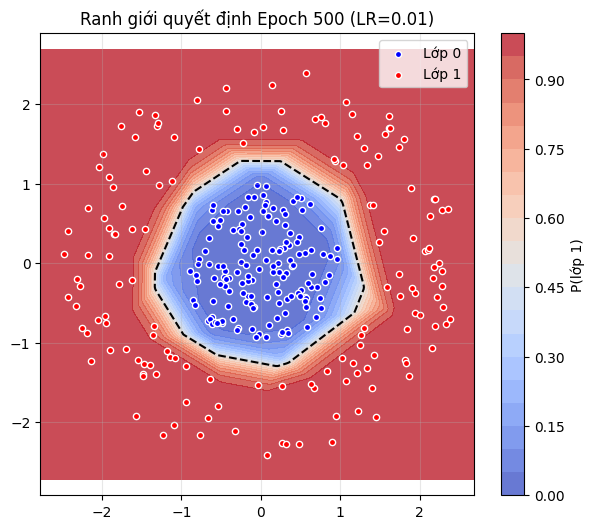

In [ ]:
def plot_decision_boundary(model_state, epoch_num, title_prefix=''):
    # Re-create the model structure
    model_to_plot = ANN([8])
    model_to_plot.load_state_dict(model_state)
    model_to_plot.eval()

    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

    with torch.no_grad():
        proba = torch.sigmoid(model_to_plot(grid)).numpy().reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    cs = plt.contourf(xx, yy, proba, levels=20, cmap='coolwarm', alpha=0.8)
    plt.scatter(X0[:, 0], X0[:, 1], color='blue', edgecolor='white', s=20, label='Lớp 0')
    plt.scatter(X1[:, 0], X1[:, 1], color='red',  edgecolor='white', s=20, label='Lớp 1')
    plt.contour(xx, yy, proba, levels=[0.5], colors='black', linestyles='--')
    plt.colorbar(cs, label='P(lớp 1)')
    plt.title(f'{title_prefix} Epoch {epoch_num} (LR=0.01)')
    plt.axis('equal'); plt.legend(); plt.grid(alpha=0.3)
    plt.show()


for epoch in save_epochs_list:
    if epoch in saved_models_lr_001:
        plot_decision_boundary(saved_models_lr_001[epoch], epoch, title_prefix='Ranh giới quyết định')
    else:
        print(f"Model state for epoch {epoch} not found.")


Epoch  100/500  loss=0.2124  test_acc=93.33%
Epoch  200/500  loss=0.0510  test_acc=100.00%
Epoch  300/500  loss=0.0244  test_acc=100.00%
Epoch  400/500  loss=0.0147  test_acc=100.00%
Epoch  500/500  loss=0.0098  test_acc=100.00%


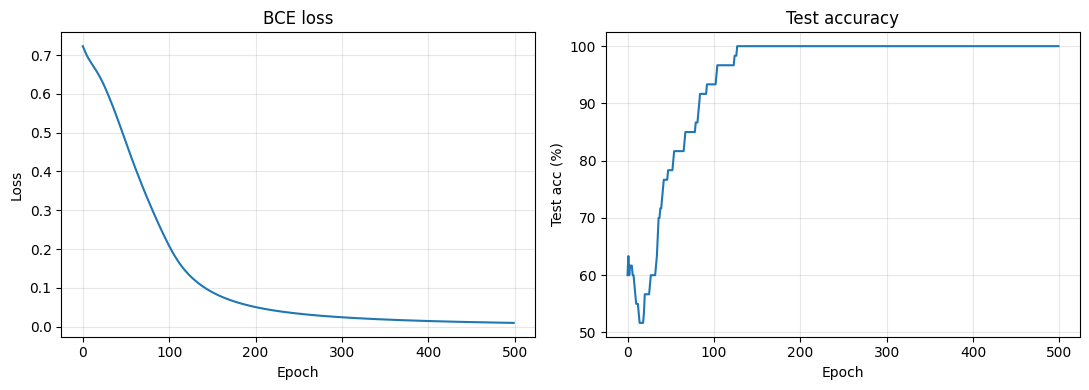

In [ ]:
model = ANN([8]) # Initialize an 8-node ANN model
criterion = nn.BCEWithLogitsLoss() # Initialize BCEWithLogitsLoss
optimizer = optim.Adam(model.parameters(), lr=0.01) # Initialize Adam optimizer

epochs = 500
loss_history, acc_history = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = (model(X_test) > 0.5).float()
        acc = (test_pred == y_test).float().mean().item()
    loss_history.append(loss.item())
    acc_history.append(acc)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d}/{epochs}  loss={loss.item():.4f}  test_acc={acc*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_history); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
axes[0].set_title('BCE loss')
axes[1].plot([a*100 for a in acc_history]); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy')
plt.tight_layout(); plt.show()

In [ ]:

model.eval()
with torch.no_grad():
    pred = (model(X_test) > 0.5).float()
    acc_ann = (pred == y_test).float().mean().item()
print(f'ANN final test accuracy: {acc_ann*100:.2f}%')
print(f'(Baseline LogReg đạt {acc_lr*100:.2f}% — ANN thắng đậm vì học được ranh giới phi tuyến.)')


ANN final test accuracy: 100.00%
(Baseline LogReg đạt 41.67% — ANN thắng đậm vì học được ranh giới phi tuyến.)


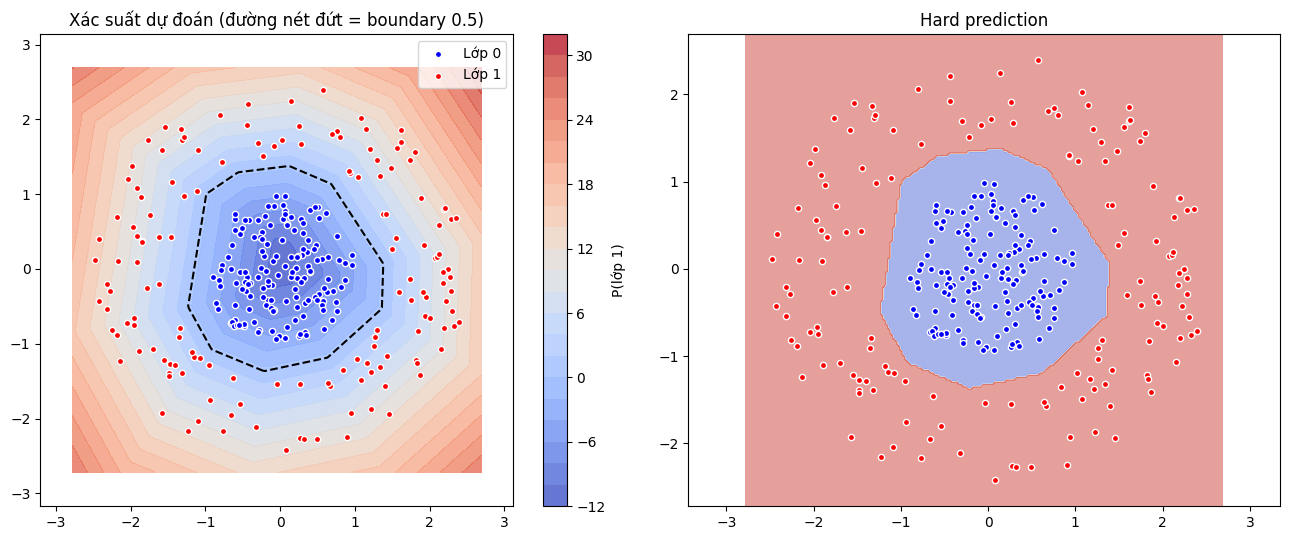

In [ ]:
x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

model.eval()
with torch.no_grad():
    proba = model(grid).numpy().reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Bên trái: contour xác suất (mềm)
cs = axes[0].contourf(xx, yy, proba, levels=20, cmap='coolwarm', alpha=0.8)
axes[0].scatter(X0[:, 0], X0[:, 1], color='blue', edgecolor='white', s=20, label='Lớp 0')
axes[0].scatter(X1[:, 0], X1[:, 1], color='red',  edgecolor='white', s=20, label='Lớp 1')
axes[0].contour(xx, yy, proba, levels=[0.5], colors='black', linestyles='--')
plt.colorbar(cs, ax=axes[0], label='P(lớp 1)')
axes[0].set_title('Xác suất dự đoán (đường nét đứt = boundary 0.5)')
axes[0].axis('equal'); axes[0].legend()

# Bên phải: hard prediction
axes[1].contourf(xx, yy, (proba > 0.5).astype(int), alpha=0.5, cmap='coolwarm')
axes[1].scatter(X0[:, 0], X0[:, 1], color='blue', edgecolor='white', s=20)
axes[1].scatter(X1[:, 0], X1[:, 1], color='red',  edgecolor='white', s=20)
axes[1].set_title('Hard prediction')
axes[1].axis('equal')

plt.tight_layout(); plt.show()

In [ ]:
from sklearn.datasets import fetch_california_housing, make_regression
from urllib.error import HTTPError
import numpy as np # Import numpy for make_regression and array operations

try:
    housing = fetch_california_housing()
    X, y = housing.data, housing.target
    feat_names = housing.feature_names
    print(f'Shape: X={X.shape}, y={y.shape}')
    print(f'Features: {feat_names}')
    print(f'Target = giá nhà (đơn vị: trăm nghìn USD)')
except HTTPError as e:
    if e.code == 403:
        print(f"Error: Could not download California Housing dataset due to a 403 Forbidden error. ")
        print(f"Using a synthetic dataset as a fallback to continue with linear regression demonstration.")
        # Fallback to a synthetic dataset with similar characteristics (8 features)
        X, y = make_regression(n_samples=20640, n_features=8, noise=0.1, random_state=42)
        feat_names = [f'Feature_{i}' for i in range(X.shape[1])] # Generate generic feature names
        print(f'Shape (synthetic): X={X.shape}, y={y.shape}')
        print(f'Features (synthetic): {feat_names}')
        print(f'Target (synthetic) = Generated regression target')
    else:
        print(f"An unexpected HTTP error occurred: {e.code} - {e.reason}")
        X, y, feat_names = np.array([]).reshape(0,8), np.array([]), [] # Ensure defined, even if empty
except Exception as e:
    print(f"An unexpected error occurred while fetching the dataset: {e}")
    X, y, feat_names = np.array([]).reshape(0,8), np.array([]), [] # Ensure defined, even if empty

# Ensure X, y, feat_names are defined, even if empty, to avoid NameError in subsequent cells
# This check handles cases where an unexpected error might bypass explicit assignment
if 'X' not in locals():
    X = np.array([]).reshape(0,8)
if 'y' not in locals():
    y = np.array([])
if 'feat_names' not in locals():
    feat_names = []


/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


Error: Could not download California Housing dataset due to a 403 Forbidden error. 
Using a synthetic dataset as a fallback to continue with linear regression demonstration.
Shape (synthetic): X=(20640, 8), y=(20640,)
Features (synthetic): ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7']
Target (synthetic) = Generated regression target


Test RMSE: 0.100  (đơn vị $100K)
Test MAE : 0.080
Test R^2 : 1.000


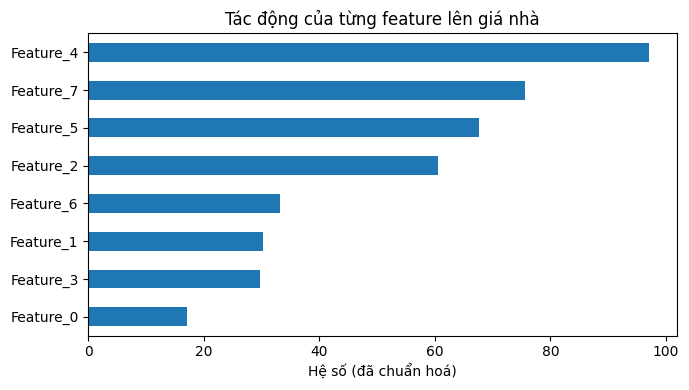

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd # Import pandas for Series

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scaling: fit chỉ trên train để tránh data leakage.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
print(f'Test RMSE: {rmse:.3f}  (đơn vị $100K)')
print(f'Test MAE : {mae:.3f}')
print(f'Test R^2 : {r2:.3f}')

# Hệ số
coef = pd.Series(model.coef_, index=feat_names).sort_values()
coef.plot.barh(figsize=(7, 4)); plt.xlabel('Hệ số (đã chuẩn hoá)')
plt.title('Tác động của từng feature lên giá nhà'); plt.tight_layout(); plt.show()

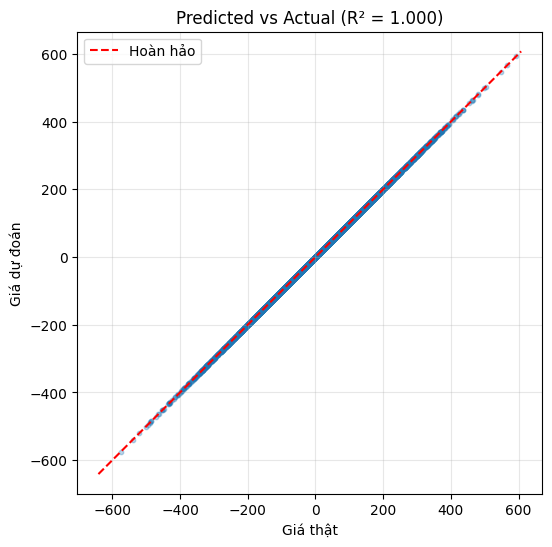

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Hoàn hảo')
plt.xlabel('Giá thật'); plt.ylabel('Giá dự đoán')
plt.title(f'Predicted vs Actual (R² = {r2:.3f})')
plt.legend(); plt.grid(alpha=0.3)
plt.axis('equal'); plt.show()